# Generate future scenario climate data

Based on script from Shijie Shi Generate_climate_forcings.ipynb

### Libraries

In [1]:
import netCDF4 as nc4
import numpy as np
from matplotlib import pyplot as plt
import copy
import pandas as pd
import time
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Parameters for calculating vapor pressure
a1=6.107799961
a2=4.436518521e-1
a3=1.428945805e-2
a4=2.650648471e-4
a5=3.031240396e-6
a6=2.034080948e-8
a7=6.136820929e-11

### Pennsylvania grid cell

In [3]:
lat = 41.05734
lon = -78.69149

if lon < 0 : 
     lon = 360 + lon
     print(lon)

281.30851


### Quick check of coordinate system

In [4]:
yr = 2015
mon = 1
ssp1 = '/global/cfs/projectdirs/m3520/share/cesm_inputdata/ssp1/monthly_data/b.e21.BSSP126cmip6.f09_g17.CMIP6-SSP1-2.6.102.cpl.ha2x3h.{}-{:02d}.nc'.format(yr,mon)
ssp1 = xr.open_dataset(ssp1, decode_times=False)


In [5]:
lat_coords = np.linspace(-90,90,len(ssp1.a2x3h_ny))
lon_coords = np.linspace(0,360,len(ssp1.a2x3h_nx))
ssp1 = ssp1.assign_coords(a2x3h_nx = lon_coords)
ssp1 = ssp1.assign_coords(a2x3h_ny = lat_coords)

In [6]:
ssp1_pa = ssp1.sel(a2x3h_nx=[lon],a2x3h_ny=[lat], method='nearest')

print(ssp1_pa.a2x3h_Sa_tbot.coords)

Coordinates:
  * time      (time) float64 0.0625 0.1875 0.3125 0.4375 ... 30.69 30.81 30.94
  * a2x3h_nx  (a2x3h_nx) float64 281.0
  * a2x3h_ny  (a2x3h_ny) float64 40.99


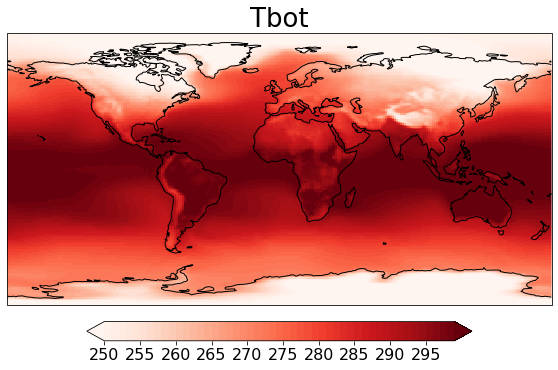

In [7]:
clevs=np.arange(250,300,1)
fig, axs = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(9,5), constrained_layout=True)

cs= ssp1.a2x3h_Sa_tbot.mean(dim='time').plot(levels=clevs,cmap='Reds', ax=axs,add_colorbar=False)
axs.set_title('Tbot', size=26)
axs.coastlines()

cbar = fig.colorbar(cs, ax=axs, location='bottom',shrink=0.6)
cbar.ax.set_title("")
cbar.ax.tick_params(labelsize=16)

### Read in the future scenario climate data
Extract PA grid cell and re-organize variables 
Note that here we do the whole time series from 2015 to 2021

In [8]:
yrs = np.arange(2015, 2101, 1).tolist()
months = np.arange(1,13,1).tolist()

print(months)
print(yrs)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100]


### SSP1 

In [9]:
# for yr in yrs  :
#     #print(yr)
#     for  mon in months : 
        
#         ssp1 = '/global/cfs/projectdirs/m3520/share/cesm_inputdata/ssp1/monthly_data/b.e21.BSSP126cmip6.f09_g17.CMIP6-SSP1-2.6.102.cpl.ha2x3h.{}-{:02d}.nc'.format(yr,mon)
#         ssp1 = xr.open_dataset(ssp1, decode_times=False)
#         ssp1 = ssp1.assign_coords(a2x3h_nx = lon_coords)
#         ssp1 = ssp1.assign_coords(a2x3h_ny = lat_coords)

#         # select the correct grid cell 
#         ssp1_pa = ssp1.sel(a2x3h_nx=[lon],a2x3h_ny=[lat], method='nearest')

#         # modify some variables
#         ssp1_pa['PRECTmms'] = ssp1_pa.a2x3h_Faxa_rainc + ssp1_pa.a2x3h_Faxa_rainl + ssp1_pa.a2x3h_Faxa_snowc + ssp1_pa.a2x3h_Faxa_snowl
#         ssp1_pa['FSDS'] = ssp1_pa.a2x3h_Faxa_swndr + ssp1_pa.a2x3h_Faxa_swvdr + ssp1_pa.a2x3h_Faxa_swndf + ssp1_pa.a2x3h_Faxa_swvdf
#         ssp1_pa['WIND'] = np.sqrt(ssp1_pa.a2x3h_Sa_u * ssp1_pa.a2x3h_Sa_u + ssp1_pa.a2x3h_Sa_v * ssp1_pa.a2x3h_Sa_v)

#         # remove those not needed
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_co2diag')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_co2prog')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_dens')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_pslv')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_ptem')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_topo')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_z')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_u')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Sa_v')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Faxa_rainc')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Faxa_rainl')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Faxa_snowc')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Faxa_snowl')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Faxa_swndr')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Faxa_swvdr')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Faxa_swndf')
#         ssp1_pa = ssp1_pa.drop_vars('a2x3h_Faxa_swvdf')

#         # not all months have all variables so get rid of domain variables
#         if 'doma_lat' in ssp1_pa: 
#             ssp1_pa = ssp1_pa.drop_vars('doma_lat')
#         if 'doma_lon' in ssp1_pa: 
#             ssp1_pa = ssp1_pa.drop_vars('doma_lon')
#         if 'doma_area' in ssp1_pa: 
#             ssp1_pa = ssp1_pa.drop_vars('doma_area')
#         if 'doma_aream' in ssp1_pa: 
#             ssp1_pa = ssp1_pa.drop_vars('doma_aream')
#         if 'doma_mask' in ssp1_pa: 
#             ssp1_pa = ssp1_pa.drop_vars('doma_mask')
#         if 'doma_frac' in ssp1_pa: 
#             ssp1_pa = ssp1_pa.drop_vars('doma_frac')
        
#         # rename the variables we do
#         ssp1_pa = ssp1_pa.rename({'a2x3h_Sa_tbot':'TBOT'})
#         ssp1_pa = ssp1_pa.rename({'a2x3h_Faxa_lwdn':'FLDS'})
#         ssp1_pa = ssp1_pa.rename({'a2x3h_Sa_pbot':'PSRF'})
#         ssp1_pa = ssp1_pa.rename({'a2x3h_Sa_shum':'QBOT'})

        
        
#         ssp1_pa.to_netcdf('/pscratch/sd/j/jneedham/fates-mrv-runs/climate-forcing/PA/ssp1/PA/CLM1PT_data/{}-{:02d}.nc'.format(yr, mon))

### SSP5

In [10]:
# for yr in yrs  :
#     #print(yr)
#     for  mon in months : 
        
#         ssp5 = '/global/cfs/projectdirs/m3520/share/cesm_inputdata/ssp5/monthly_data/b.e21.BSSP585cmip6.f09_g17.CMIP6-SSP5-8.5.102.cpl.ha2x3h.{}-{:02d}.nc'.format(yr,mon)
#         ssp5 = xr.open_dataset(ssp5, decode_times=False)
#         ssp5 = ssp5.assign_coords(a2x3h_nx = lon_coords)
#         ssp5 = ssp5.assign_coords(a2x3h_ny = lat_coords)

#         # select the correct grid cell 
#         ssp5_pa = ssp5.sel(a2x3h_nx=[lon],a2x3h_ny=[lat], method='nearest')

#         # modify some variables
#         ssp5_pa['PRECTmms'] = ssp5_pa.a2x3h_Faxa_rainc + ssp5_pa.a2x3h_Faxa_rainl + ssp5_pa.a2x3h_Faxa_snowc + ssp5_pa.a2x3h_Faxa_snowl
#         ssp5_pa['FSDS'] = ssp5_pa.a2x3h_Faxa_swndr + ssp5_pa.a2x3h_Faxa_swvdr + ssp5_pa.a2x3h_Faxa_swndf + ssp5_pa.a2x3h_Faxa_swvdf
#         ssp5_pa['WIND'] = np.sqrt(ssp5_pa.a2x3h_Sa_u * ssp5_pa.a2x3h_Sa_u + ssp5_pa.a2x3h_Sa_v * ssp5_pa.a2x3h_Sa_v)

#         # remove those not needed
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_co2diag')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_co2prog')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_dens')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_pslv')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_ptem')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_topo')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_z')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_u')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Sa_v')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Faxa_rainc')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Faxa_rainl')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Faxa_snowc')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Faxa_snowl')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Faxa_swndr')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Faxa_swvdr')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Faxa_swndf')
#         ssp5_pa = ssp5_pa.drop_vars('a2x3h_Faxa_swvdf')

#         # not all months have doma
#         if 'doma_lat' in ssp5_pa: 
#             ssp5_pa = ssp5_pa.drop_vars('doma_lat')
#         if 'doma_lon' in ssp5_pa: 
#             ssp5_pa = ssp5_pa.drop_vars('doma_lon')   
#         if 'doma_area' in ssp5_pa: 
#             ssp5_pa = ssp5_pa.drop_vars('doma_area')
#         if 'doma_aream' in ssp5_pa: 
#             ssp5_pa = ssp5_pa.drop_vars('doma_aream')
#         if 'doma_mask' in ssp5_pa: 
#             ssp5_pa = ssp5_pa.drop_vars('doma_mask')
#         if 'doma_frac' in ssp5_pa: 
#             ssp5_pa = ssp5_pa.drop_vars('doma_frac')
        
#         # rename the variables we do
#         ssp5_pa = ssp5_pa.rename({'a2x3h_Sa_tbot':'TBOT'})
#         ssp5_pa = ssp5_pa.rename({'a2x3h_Faxa_lwdn':'FLDS'})
#         ssp5_pa = ssp5_pa.rename({'a2x3h_Sa_pbot':'PSRF'})
#         ssp5_pa = ssp5_pa.rename({'a2x3h_Sa_shum':'QBOT'})

#         ssp5_pa.to_netcdf('/pscratch/sd/j/jneedham/fates-mrv-runs/climate-forcing/PA/ssp5/PA/CLM1PT_data/{}-{:02d}.nc'.format(yr, mon))

## Bias correction using historical data

Use the overlaping years between ERA5 and SSPs to find the bias.
Apply the bias correction to the  whole future time series 

#### First get overlapping time series 

#### ERA 5 - hourly

In [11]:
yrs = np.arange(2015, 2023, 1).tolist()
months = np.arange(1,13,1).tolist()

files = []

# E3SMv1 - 3 hourly
for yr in yrs  :
    for  mon in months : 
        era5 = '/pscratch/sd/j/jneedham/fates-mrv-runs/PA/CLM1PT_data/{}-{:02d}.nc'.format(yr,mon)
        files.append(xr.open_dataset(era5))


era5_ts = xr.concat(files, dim='time')

#### SSPs - 3 hourly 

In [12]:
files = []
for yr in yrs  :
    for  mon in months : 
        ssp1 = '/pscratch/sd/j/jneedham/fates-mrv-runs/climate-forcing/PA/ssp1/PA/CLM1PT_data/{}-{:02d}.nc'.format(yr,mon)
        files.append(xr.open_dataset(ssp1))


ssp1_ts = xr.concat(files, dim='time')

In [13]:
files = []
for yr in yrs  :
    for  mon in months : 
        ssp5 = '/pscratch/sd/j/jneedham/fates-mrv-runs/climate-forcing/PA/ssp5/PA/CLM1PT_data/{}-{:02d}.nc'.format(yr,mon)
        files.append(xr.open_dataset(ssp5))


ssp5_ts = xr.concat(files, dim='time')

In [14]:
ssp1_ts = ssp1_ts.rename_dims({'a2x3h_ny': 'lat','a2x3h_nx':'lon'})
ssp5_ts = ssp5_ts.rename_dims({'a2x3h_ny': 'lat','a2x3h_nx':'lon'})

#### Find the mean for each month

In [15]:
era_tbot_mm = era5_ts['TBOT'].groupby('time.month').mean('time')
era_flds_mm = era5_ts['FLDS'].groupby('time.month').mean('time')
era_fsds_mm = era5_ts['FSDS'].groupby('time.month').mean('time')
era_prect_mm = era5_ts['PRECTmms'].groupby('time.month').mean('time')
era_psrf_mm = era5_ts['PSRF'].groupby('time.month').mean('time')
era_rh_mm = era5_ts['RH'].groupby('time.month').mean('time')
era_wind_mm = era5_ts['WIND'].groupby('time.month').mean('time')


In [16]:
ssp1_tbot_mm = ssp1_ts['TBOT'].groupby('time.month').mean('time')
ssp1_flds_mm = ssp1_ts['FLDS'].groupby('time.month').mean('time')
ssp1_fsds_mm = ssp1_ts['FSDS'].groupby('time.month').mean('time')
ssp1_prect_mm = ssp1_ts['PRECTmms'].groupby('time.month').mean('time')
ssp1_psrf_mm = ssp1_ts['PSRF'].groupby('time.month').mean('time')
ssp1_wind_mm = ssp1_ts['WIND'].groupby('time.month').mean('time')
ssp1_qbot_mm = ssp1_ts['QBOT'].groupby('time.month').mean('time')


In [17]:
ssp5_tbot_mm = ssp5_ts['TBOT'].groupby('time.month').mean('time')
ssp5_flds_mm = ssp5_ts['FLDS'].groupby('time.month').mean('time')
ssp5_fsds_mm = ssp5_ts['FSDS'].groupby('time.month').mean('time')
ssp5_prect_mm = ssp5_ts['PRECTmms'].groupby('time.month').mean('time')
ssp5_psrf_mm = ssp5_ts['PSRF'].groupby('time.month').mean('time')
ssp5_wind_mm = ssp5_ts['WIND'].groupby('time.month').mean('time')
ssp5_qbot_mm = ssp5_ts['QBOT'].groupby('time.month').mean('time')

### Plot seasonal cycle to visually assess bias 

Text(0.5, 0, 'Time (months)')

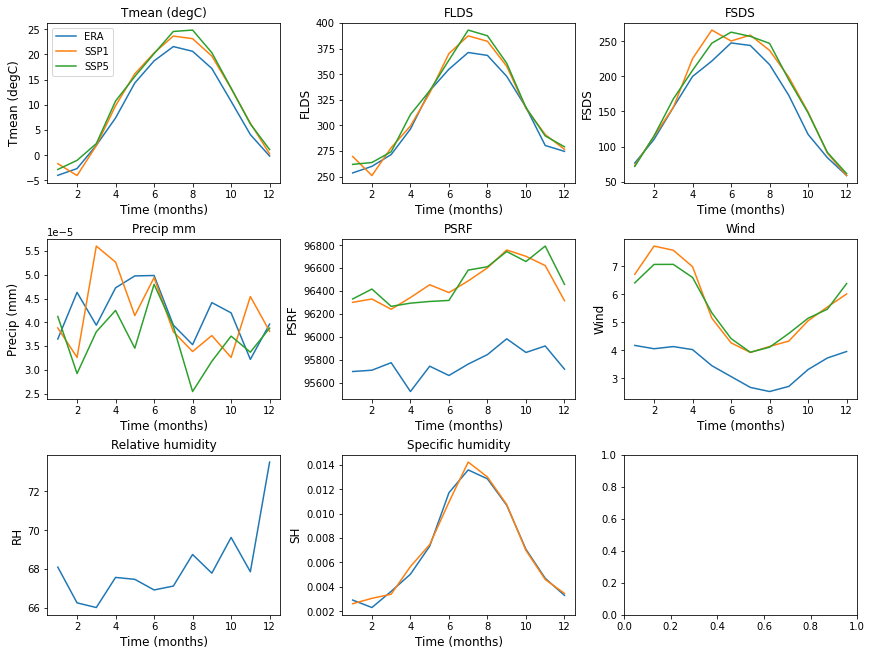

In [18]:
mons = np.arange(1,13,1)

# quick plots as a sanity check  - seasonal cycle
fig1, ((f1ax0,f1ax1,f1ax2),(f1ax3,f1ax4,f1ax5),(f1ax6,f1ax7,f1ax8)) = plt.subplots(nrows=3,ncols=3, 
                                                                                   figsize=(12,9), constrained_layout=True)


f1ax0.plot(mons, np.squeeze(era_tbot_mm)- 273.16, label='ERA')    
f1ax1.plot(mons, np.squeeze(era_flds_mm))
f1ax2.plot(mons, np.squeeze(era_fsds_mm))
f1ax3.plot(mons, np.squeeze(era_prect_mm))
f1ax4.plot(mons, np.squeeze(era_psrf_mm))
f1ax5.plot(mons, np.squeeze(era_wind_mm))
f1ax6.plot(mons, np.squeeze(era_rh_mm))

f1ax0.plot(mons, np.squeeze(ssp1_tbot_mm)- 273.16, label='SSP1')    
f1ax1.plot(mons, np.squeeze(ssp1_flds_mm))
f1ax2.plot(mons, np.squeeze(ssp1_fsds_mm))
f1ax3.plot(mons, np.squeeze(ssp1_prect_mm))
f1ax4.plot(mons, np.squeeze(ssp1_psrf_mm))
f1ax5.plot(mons, np.squeeze(ssp1_wind_mm))
f1ax7.plot(mons, np.squeeze(ssp1_qbot_mm))

f1ax0.plot(mons, np.squeeze(ssp5_tbot_mm)- 273.16, label='SSP5')    
f1ax1.plot(mons, np.squeeze(ssp5_flds_mm))
f1ax2.plot(mons, np.squeeze(ssp5_fsds_mm))
f1ax3.plot(mons, np.squeeze(ssp5_prect_mm))
f1ax4.plot(mons, np.squeeze(ssp5_psrf_mm))
f1ax5.plot(mons, np.squeeze(ssp5_wind_mm))
f1ax7.plot(mons, np.squeeze(ssp5_qbot_mm))

f1ax0.legend()

f1ax0.set_title(r'Tmean (degC)', fontsize = 12)
f1ax0.set_ylabel(r'Tmean (degC)', fontsize = 12)
f1ax0.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax1.set_title(r'FLDS', fontsize = 12)
f1ax1.set_ylabel(r'FLDS', fontsize = 12)
f1ax1.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax2.set_title(r'FSDS', fontsize = 12)
f1ax2.set_ylabel(r'FSDS', fontsize = 12)
f1ax2.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax3.set_title(r'Precip mm', fontsize = 12)
f1ax3.set_ylabel(r'Precip (mm)', fontsize = 12)
f1ax3.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax4.set_title(r'PSRF', fontsize = 12)
f1ax4.set_ylabel(r'PSRF', fontsize = 12)
f1ax4.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax5.set_title(r'Wind', fontsize = 12)
f1ax5.set_ylabel(r'Wind', fontsize = 12)
f1ax5.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax6.set_title(r'Relative humidity', fontsize = 12)
f1ax6.set_ylabel(r'RH', fontsize = 12)
f1ax6.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax7.set_title(r'Specific humidity', fontsize = 12)
f1ax7.set_ylabel(r'SH', fontsize = 12)
f1ax7.set_xlabel(r'Time (months)', fontsize = 12) 


### Plot time series of overlap

In [19]:
era_time = np.arange(0,len(era5_ts.time),1)
ssp_time = np.arange(0,len(era5_ts.time),3)

Text(0.5, 0, 'Time')

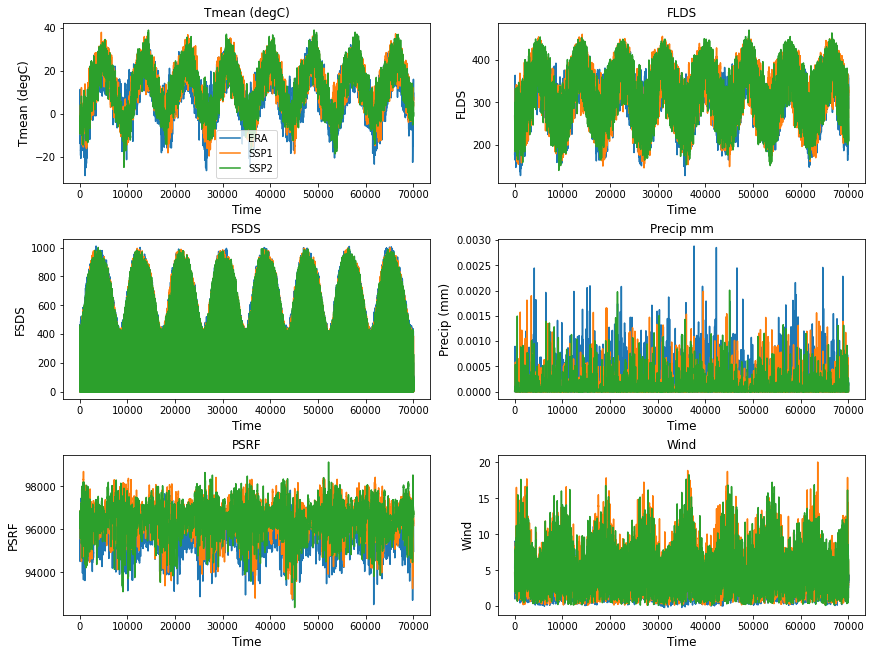

In [20]:
# quick plots as a sanity check  - seasonal cycle
fig1, ((f1ax0, f1ax1),(f1ax2, f1ax3),(f1ax4,f1ax5)) = plt.subplots(nrows=3,ncols=2, figsize=(12,9), constrained_layout=True)


f1ax0.plot(era_time, np.squeeze(era5_ts.TBOT)- 273.16, label='ERA')    
f1ax1.plot(era_time, np.squeeze(era5_ts.FLDS))
f1ax2.plot(era_time, np.squeeze(era5_ts.FSDS))
f1ax3.plot(era_time, np.squeeze(era5_ts.PRECTmms))
f1ax4.plot(era_time, np.squeeze(era5_ts.PSRF))
f1ax5.plot(era_time, np.squeeze(era5_ts.WIND))

f1ax0.plot(ssp_time, np.squeeze(ssp1_ts.TBOT)- 273.16, label='SSP1')    
f1ax1.plot(ssp_time, np.squeeze(ssp1_ts.FLDS))
f1ax2.plot(ssp_time, np.squeeze(ssp1_ts.FSDS))
f1ax3.plot(ssp_time, np.squeeze(ssp1_ts.PRECTmms))
f1ax4.plot(ssp_time,np.squeeze(ssp1_ts.PSRF))
f1ax5.plot(ssp_time,np.squeeze(ssp1_ts.WIND))

f1ax0.plot(ssp_time,np.squeeze(ssp5_ts.TBOT)- 273.16, label='SSP2')    
f1ax1.plot(ssp_time,np.squeeze(ssp5_ts.FLDS))
f1ax2.plot(ssp_time,np.squeeze(ssp5_ts.FSDS))
f1ax3.plot(ssp_time,np.squeeze(ssp5_ts.PRECTmms))
f1ax4.plot(ssp_time,np.squeeze(ssp5_ts.PSRF))
f1ax5.plot(ssp_time,np.squeeze(ssp5_ts.WIND))

f1ax0.legend()

f1ax0.set_title(r'Tmean (degC)', fontsize = 12)
f1ax0.set_ylabel(r'Tmean (degC)', fontsize = 12)
f1ax0.set_xlabel(r'Time', fontsize = 12)    

f1ax1.set_title(r'FLDS', fontsize = 12)
f1ax1.set_ylabel(r'FLDS', fontsize = 12)
f1ax1.set_xlabel(r'Time', fontsize = 12)    

f1ax2.set_title(r'FSDS', fontsize = 12)
f1ax2.set_ylabel(r'FSDS', fontsize = 12)
f1ax2.set_xlabel(r'Time', fontsize = 12)    

f1ax3.set_title(r'Precip mm', fontsize = 12)
f1ax3.set_ylabel(r'Precip (mm)', fontsize = 12)
f1ax3.set_xlabel(r'Time', fontsize = 12) 

f1ax4.set_title(r'PSRF', fontsize = 12)
f1ax4.set_ylabel(r'PSRF', fontsize = 12)
f1ax4.set_xlabel(r'Time', fontsize = 12) 

f1ax5.set_title(r'Wind', fontsize = 12)
f1ax5.set_ylabel(r'Wind', fontsize = 12)
f1ax5.set_xlabel(r'Time', fontsize = 12) 

### Get the corrections for each month

In [21]:
tbot_ssp1_corr = era_tbot_mm - ssp1_tbot_mm
wind_ssp1_corr = era_wind_mm - ssp1_wind_mm
fsds_ssp1_corr = era_fsds_mm / ssp1_fsds_mm
flds_ssp1_corr = era_flds_mm / ssp1_flds_mm
psrf_ssp1_corr = era_psrf_mm - ssp1_psrf_mm
prect_ssp1_corr = era_prect_mm / ssp1_prect_mm


In [22]:
tbot_ssp5_corr = era_tbot_mm - ssp5_tbot_mm
wind_ssp5_corr = era_wind_mm - ssp5_wind_mm
fsds_ssp5_corr = era_fsds_mm / ssp5_fsds_mm
flds_ssp5_corr = era_flds_mm / ssp5_flds_mm
psrf_ssp5_corr = era_psrf_mm - ssp5_psrf_mm
prect_ssp5_corr = era_prect_mm / ssp5_prect_mm

### Read in the full ssp time series 

In [23]:
yrs = np.arange(2015, 2101, 1).tolist()
months = np.arange(1,13,1).tolist()


In [24]:
files = []
for yr in yrs  :
    for  mon in months : 
        ssp1 = '/pscratch/sd/j/jneedham/fates-mrv-runs/climate-forcing/PA/ssp1/PA/CLM1PT_data/{}-{:02d}.nc'.format(yr,mon)
        files.append(xr.open_dataset(ssp1))


ssp1_ts = xr.concat(files, dim='time')

In [25]:
ssp1_ts = ssp1_ts.rename_dims({'a2x3h_ny': 'lat','a2x3h_nx':'lon'})

In [26]:
files = []
for yr in yrs  :
    for  mon in months : 
        ssp5 = '/pscratch/sd/j/jneedham/fates-mrv-runs/climate-forcing/PA/ssp5/PA/CLM1PT_data/{}-{:02d}.nc'.format(yr,mon)
        files.append(xr.open_dataset(ssp5))


ssp5_ts = xr.concat(files, dim='time')

In [27]:
ssp5_ts = ssp5_ts.rename_dims({'a2x3h_ny': 'lat','a2x3h_nx':'lon'})

### Apply the corrections 

In [28]:
monthly_offsets = ssp1_ts['time'].dt.month # month of each time step


In [29]:
### SSP 1
add_vals = tbot_ssp1_corr.sel(month=monthly_offsets) # correction value for each time step
ssp1_ts['TBOT_corr'] = ssp1_ts['TBOT'] + add_vals # add a new corrected variable 

add_vals = psrf_ssp1_corr.sel(month=monthly_offsets)
ssp1_ts['PSRF_corr'] = ssp1_ts['PSRF'] + add_vals

add_vals = wind_ssp1_corr.sel(month=monthly_offsets) # correction value for each time step
ssp1_ts['WIND_corr'] = ssp1_ts['WIND'] + add_vals # add a new corrected variable 


#### Relative humidity
In correcting the ERA5 bias with Terraclimate and Daymet we calculated relative humidity from dew point temperature. 
The SSPs have specific humidity. We calcualte ea for both ERA5 and SSPs, bias correct ea, and then convert to RH.  

In [30]:
# Calculate actual vapour pressure
# For ERA we go from relative humidity  and temperature
tbot_era_c = era5_ts['TBOT'] - 273.16
# calculate saturation vapour pressure
era_es = a1 + tbot_era_c * (a2 + tbot_era_c * (a3 + tbot_era_c * (a4 + tbot_era_c * (a5 + tbot_era_c * (a6 + tbot_era_c * a7)))))
# calculate vapour pressure
era_ea =  era5_ts['RH'] * era_es * 0.01 # for  ERA5 calculated based on RH

# For SSPs use specific humidity and pressure
qbot = ssp1_ts['QBOT'].sel(time=slice("2015-01-01", "2022-12-31"))
psrf = ssp1_ts['PSRF_corr'].sel(time=slice("2015-01-01", "2022-12-31"))
ssp1_ea = 0.01*(qbot * psrf) / (0.62198+0.377* qbot)

# get the monthly means
era_ea_mm = era_ea.groupby('time.month').mean('time')
ssp1_ea_mm = ssp1_ea.groupby('time.month').mean('time')
#  GET THE CORRECTION
ea_corr = era_ea_mm / ssp1_ea_mm
add_vals = ea_corr.sel(month=monthly_offsets) # correction value for each time step

# now back to the whole time series
ssp1_ea = 0.01*(ssp1_ts['QBOT'] * ssp1_ts['PSRF_corr']) / (0.62198+0.377* ssp1_ts['QBOT']) # vapour pressure from specific humidity  and pressure
ssp1_ea_corr = ssp1_ea * add_vals # add a new corrected variable - whole  time series corrected vapour pressure

#  monthly means of corrected vapour pressure
ssp1_ea_mm_corr = ssp1_ea_corr.sel(time=slice("2015-01-01","2022-12-31")).groupby('time.month').mean('time')

# convert vapour pressure to RH
# first calculate saturation vapour pressure
tbot_ssp1_c = ssp1_ts['TBOT_corr'] - 273.16  
ssp1_es = a1 + tbot_ssp1_c * (a2 + tbot_ssp1_c * (a3 + tbot_ssp1_c * (a4 + tbot_ssp1_c * (a5 + tbot_ssp1_c * (a6 + tbot_ssp1_c * a7)))))

ssp1_ts['RH'] = ssp1_ea_corr / (ssp1_es * 0.01) 

# monthly means of RH
era_rh_mm = era5_ts['RH'].groupby('time.month').mean('time')
ssp1_rh_mm_corr = ssp1_ts['RH'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')

# monthly means of ES
era_es_mm = era_es.groupby('time.month').mean('time')
ssp1_es_mm_corr = ssp1_es.sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')


Text(0, 0.5, 'ES')

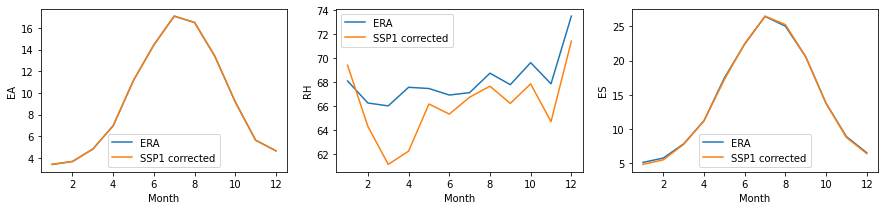

In [31]:
mons = np.arange(1,13,1)

# quick plots as a sanity check  - seasonal cycle
fig1, ((f1ax0,f1ax1, f1ax2)) = plt.subplots(nrows=1,ncols=3, figsize=(15,3))

f1ax0.plot(mons, np.squeeze(era_ea_mm), label='ERA') 
f1ax0.plot(mons, np.squeeze(ssp1_ea_mm_corr), label='SSP1 corrected')
#f1ax0.plot(mons, np.squeeze(ssp1_ea_mm), label='SSP1')

f1ax0.legend()
f1ax0.set_xlabel('Month')
f1ax0.set_ylabel('EA')

f1ax1.plot(mons, np.squeeze(era_rh_mm), label='ERA') 
f1ax1.plot(mons, np.squeeze(ssp1_rh_mm_corr), label='SSP1 corrected')
#f1ax1.plot(mons, np.squeeze(era_rh_mm_test), label ='ERA test')

f1ax1.legend()
f1ax1.set_xlabel('Month')
f1ax1.set_ylabel('RH')

f1ax2.plot(mons, np.squeeze(era_es_mm), label='ERA') 
f1ax2.plot(mons, np.squeeze(ssp1_es_mm_corr), label='SSP1 corrected')
f1ax2.legend()
f1ax2.set_xlabel('Month')
f1ax2.set_ylabel('ES')

In [32]:
add_vals = fsds_ssp1_corr.sel(month=monthly_offsets)
ssp1_ts['FSDS_corr'] = ssp1_ts['FSDS'] * add_vals

add_vals = flds_ssp1_corr.sel(month=monthly_offsets)
ssp1_ts['FLDS_corr'] = ssp1_ts['FLDS'] * add_vals

add_vals = prect_ssp1_corr.sel(month=monthly_offsets)
ssp1_ts['PRECTmms_corr'] = ssp1_ts['PRECTmms'] * add_vals

In [33]:
### SSP 5
add_vals = tbot_ssp5_corr.sel(month=monthly_offsets) # correction value for each time step
ssp5_ts['TBOT_corr'] = ssp5_ts['TBOT'] + add_vals # add a new corrected variable 

add_vals = psrf_ssp5_corr.sel(month=monthly_offsets)
ssp5_ts['PSRF_corr'] = ssp5_ts['PSRF'] + add_vals

add_vals = wind_ssp5_corr.sel(month=monthly_offsets) # correction value for each time step
ssp5_ts['WIND_corr'] = ssp5_ts['WIND'] + add_vals # add a new corrected variable 


In [34]:
tbot_era_c = era5_ts['TBOT'] - 273.16
tbot_ssp5_c = ssp5_ts['TBOT_corr'].sel(time=slice("2015-01-01", "2022-12-31")) - 273.16  # pull out the overlap years

era_es = a1 + tbot_era_c * (a2 + tbot_era_c * (a3 + tbot_era_c * (a4 + tbot_era_c * (a5 + tbot_era_c * (a6 + tbot_era_c * a7)))))
ssp5_es = a1 + tbot_ssp5_c * (a2 + tbot_ssp5_c * (a3 + tbot_ssp5_c * (a4 + tbot_ssp5_c * (a5 + tbot_ssp5_c * (a6 + tbot_ssp5_c * a7)))))

era_ea =  era5_ts['RH'] * era_es * 0.01
qbot = ssp5_ts['QBOT'].sel(time=slice("2015-01-01", "2022-12-31"))
psrf = ssp5_ts['PSRF_corr'].sel(time=slice("2015-01-01", "2022-12-31"))
ssp5_ea = 0.01*(qbot * psrf) / (0.62198+0.377* qbot)

# get the monthly means
era_ea_mm = era_ea.groupby('time.month').mean('time')
ssp5_ea_mm = ssp5_ea.groupby('time.month').mean('time')
ea_corr = era_ea_mm / ssp5_ea_mm
add_vals = ea_corr.sel(month=monthly_offsets) # correction value for each time step

# now back to the whole time series
ssp5_ea = 0.01*(ssp5_ts['QBOT'] * ssp5_ts['PSRF_corr']) / (0.62198+0.377* ssp5_ts['QBOT'])
ssp5_ea_corr = ssp5_ea * add_vals # add a new corrected variable 

# now convert to RH
tbot_ssp5_c = ssp5_ts['TBOT_corr'] - 273.16  
ssp5_es = a1 + tbot_ssp5_c * (a2 + tbot_ssp5_c * (a3 + tbot_ssp5_c * (a4 + tbot_ssp5_c * (a5 + tbot_ssp5_c * (a6 + tbot_ssp5_c * a7)))))

ssp5_ts['RH'] = ssp5_ea_corr / (ssp5_es * 0.01)

In [35]:
add_vals = fsds_ssp5_corr.sel(month=monthly_offsets)
ssp5_ts['FSDS_corr'] = ssp5_ts['FSDS'] * add_vals

add_vals = flds_ssp5_corr.sel(month=monthly_offsets)
ssp5_ts['FLDS_corr'] = ssp5_ts['FLDS'] * add_vals

add_vals = prect_ssp5_corr.sel(month=monthly_offsets)
ssp5_ts['PRECTmms_corr'] = ssp5_ts['PRECTmms'] * add_vals

### Check it worked

Plot the new monthly means, just for the overlap period

In [36]:
ssp1_tbot_mm_corr = ssp1_ts['TBOT_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp1_psrf_mm_corr = ssp1_ts['PSRF_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp1_fsds_mm_corr = ssp1_ts['FSDS_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp1_flds_mm_corr = ssp1_ts['FLDS_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp1_wind_mm_corr = ssp1_ts['WIND_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp1_prect_mm_corr = ssp1_ts['PRECTmms_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp1_rh_mm_corr = ssp1_ts['RH'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')

ssp5_psrf_mm_corr = ssp5_ts['PSRF_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp5_tbot_mm_corr = ssp5_ts['TBOT_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp5_fsds_mm_corr = ssp5_ts['FSDS_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp5_flds_mm_corr = ssp5_ts['FLDS_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp5_wind_mm_corr = ssp5_ts['WIND_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp5_prect_mm_corr = ssp5_ts['PRECTmms_corr'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')
ssp5_rh_mm_corr = ssp5_ts['RH'].sel(time=slice("2015-01-01", "2022-12-31")).groupby('time.month').mean('time')

Text(0.5, 0, 'Time (months)')

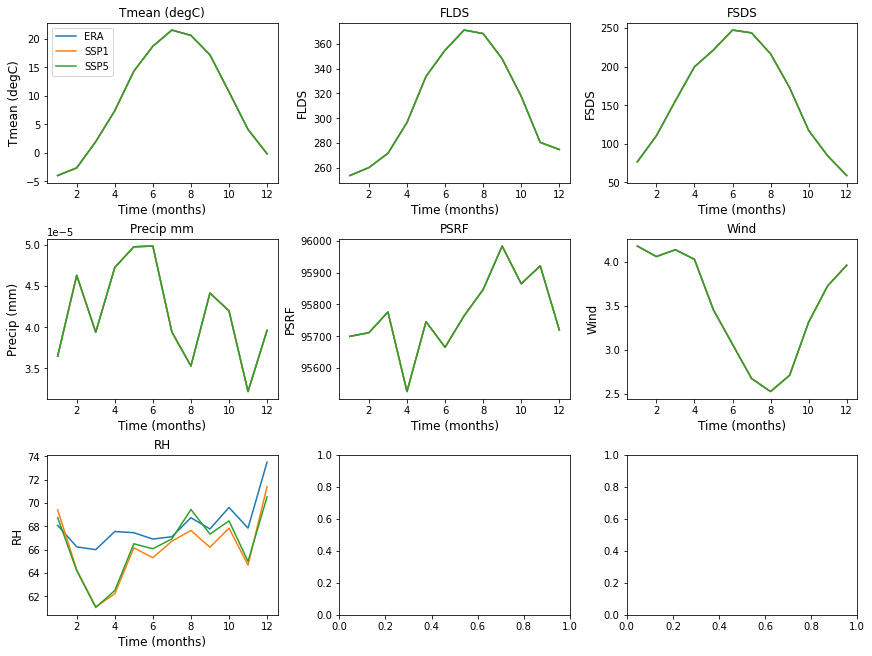

In [37]:
mons = np.arange(1,13,1)

# quick plots as a sanity check  - seasonal cycle
fig1, ((f1ax0,f1ax1,f1ax2),(f1ax3,f1ax4,f1ax5),(f1ax6,f1ax7,f1ax8)) = plt.subplots(nrows=3,ncols=3, 
                                                                                   figsize=(12,9), constrained_layout=True)


f1ax0.plot(mons, np.squeeze(era_tbot_mm)- 273.16, label='ERA')    
f1ax1.plot(mons, np.squeeze(era_flds_mm))
f1ax2.plot(mons, np.squeeze(era_fsds_mm))
f1ax3.plot(mons, np.squeeze(era_prect_mm))
f1ax4.plot(mons, np.squeeze(era_psrf_mm))
f1ax5.plot(mons, np.squeeze(era_wind_mm))
f1ax6.plot(mons, np.squeeze(era_rh_mm))

f1ax0.plot(mons, np.squeeze(ssp1_tbot_mm_corr)- 273.16, label='SSP1')    
f1ax1.plot(mons, np.squeeze(ssp1_flds_mm_corr))
f1ax2.plot(mons, np.squeeze(ssp1_fsds_mm_corr))
f1ax3.plot(mons, np.squeeze(ssp1_prect_mm_corr))
f1ax4.plot(mons, np.squeeze(ssp1_psrf_mm_corr))
f1ax5.plot(mons, np.squeeze(ssp1_wind_mm_corr))
f1ax6.plot(mons, np.squeeze(ssp1_rh_mm_corr))

f1ax0.plot(mons, np.squeeze(ssp5_tbot_mm_corr)- 273.16, label='SSP5')    
f1ax1.plot(mons, np.squeeze(ssp5_flds_mm_corr))
f1ax2.plot(mons, np.squeeze(ssp5_fsds_mm_corr))
f1ax3.plot(mons, np.squeeze(ssp5_prect_mm_corr))
f1ax4.plot(mons, np.squeeze(ssp5_psrf_mm_corr))
f1ax5.plot(mons, np.squeeze(ssp5_wind_mm_corr))
f1ax6.plot(mons, np.squeeze(ssp5_rh_mm_corr))

f1ax0.legend()

f1ax0.set_title(r'Tmean (degC)', fontsize = 12)
f1ax0.set_ylabel(r'Tmean (degC)', fontsize = 12)
f1ax0.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax1.set_title(r'FLDS', fontsize = 12)
f1ax1.set_ylabel(r'FLDS', fontsize = 12)
f1ax1.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax2.set_title(r'FSDS', fontsize = 12)
f1ax2.set_ylabel(r'FSDS', fontsize = 12)
f1ax2.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax3.set_title(r'Precip mm', fontsize = 12)
f1ax3.set_ylabel(r'Precip (mm)', fontsize = 12)
f1ax3.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax4.set_title(r'PSRF', fontsize = 12)
f1ax4.set_ylabel(r'PSRF', fontsize = 12)
f1ax4.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax5.set_title(r'Wind', fontsize = 12)
f1ax5.set_ylabel(r'Wind', fontsize = 12)
f1ax5.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax6.set_title(r'RH', fontsize = 12)
f1ax6.set_ylabel(r'RH', fontsize = 12)
f1ax6.set_xlabel(r'Time (months)', fontsize = 12) 



### Monthly means of the whole time series

In [38]:
ssp1_tbot_mm_corr = ssp1_ts['TBOT_corr'].groupby('time.month').mean('time')
ssp1_psrf_mm_corr = ssp1_ts['PSRF_corr'].groupby('time.month').mean('time')
ssp1_fsds_mm_corr = ssp1_ts['FSDS_corr'].groupby('time.month').mean('time')
ssp1_flds_mm_corr = ssp1_ts['FLDS_corr'].groupby('time.month').mean('time')
ssp1_wind_mm_corr = ssp1_ts['WIND_corr'].groupby('time.month').mean('time')
ssp1_prect_mm_corr = ssp1_ts['PRECTmms_corr'].groupby('time.month').mean('time')
ssp1_rh_mm_corr = ssp1_ts['RH'].groupby('time.month').mean('time')

ssp5_psrf_mm_corr = ssp5_ts['PSRF_corr'].groupby('time.month').mean('time')
ssp5_tbot_mm_corr = ssp5_ts['TBOT_corr'].groupby('time.month').mean('time')
ssp5_fsds_mm_corr = ssp5_ts['FSDS_corr'].groupby('time.month').mean('time')
ssp5_flds_mm_corr = ssp5_ts['FLDS_corr'].groupby('time.month').mean('time')
ssp5_wind_mm_corr = ssp5_ts['WIND_corr'].groupby('time.month').mean('time')
ssp5_prect_mm_corr = ssp5_ts['PRECTmms_corr'].groupby('time.month').mean('time')
ssp5_rh_mm_corr = ssp5_ts['RH'].groupby('time.month').mean('time')

Text(0.5, 0, 'Time (months)')

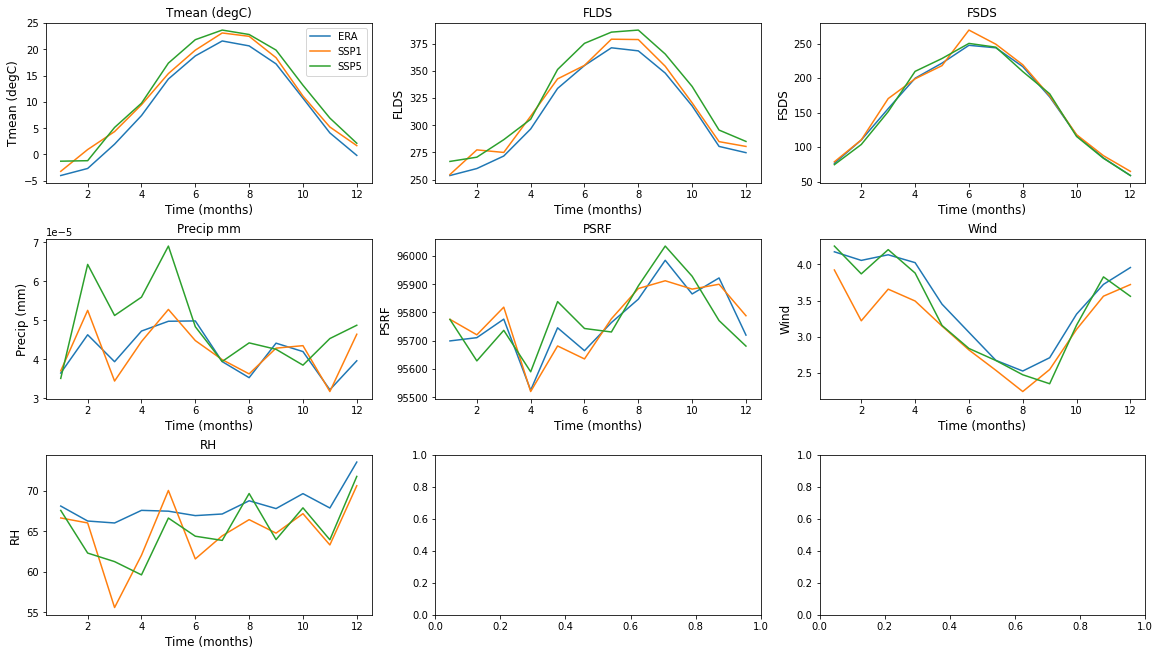

In [39]:
mons = np.arange(1,13,1)

# quick plots as a sanity check  - seasonal cycle
fig1, ((f1ax0,f1ax1,f1ax2),(f1ax3,f1ax4,f1ax5),(f1ax6,f1ax7,f1ax8)) = plt.subplots(nrows=3,ncols=3, 
                                                                                   figsize=(16,9), constrained_layout=True)

f1ax0.plot(mons, np.squeeze(era_tbot_mm)- 273.16, label='ERA')    
f1ax1.plot(mons, np.squeeze(era_flds_mm))
f1ax2.plot(mons, np.squeeze(era_fsds_mm))
f1ax3.plot(mons, np.squeeze(era_prect_mm))
f1ax4.plot(mons, np.squeeze(era_psrf_mm))
f1ax5.plot(mons, np.squeeze(era_wind_mm))
f1ax6.plot(mons, np.squeeze(era_rh_mm))

f1ax0.plot(mons, np.squeeze(ssp1_tbot_mm_corr)- 273.16, label='SSP1')    
f1ax1.plot(mons, np.squeeze(ssp1_flds_mm_corr))
f1ax2.plot(mons, np.squeeze(ssp1_fsds_mm_corr))
f1ax3.plot(mons, np.squeeze(ssp1_prect_mm_corr))
f1ax4.plot(mons, np.squeeze(ssp1_psrf_mm_corr))
f1ax5.plot(mons, np.squeeze(ssp1_wind_mm_corr))
f1ax6.plot(mons, np.squeeze(ssp1_rh_mm_corr))

f1ax0.plot(mons, np.squeeze(ssp5_tbot_mm_corr)- 273.16, label='SSP5')    
f1ax1.plot(mons, np.squeeze(ssp5_flds_mm_corr))
f1ax2.plot(mons, np.squeeze(ssp5_fsds_mm_corr))
f1ax3.plot(mons, np.squeeze(ssp5_prect_mm_corr))
f1ax4.plot(mons, np.squeeze(ssp5_psrf_mm_corr))
f1ax5.plot(mons, np.squeeze(ssp5_wind_mm_corr))
f1ax6.plot(mons, np.squeeze(ssp5_rh_mm_corr))

f1ax0.legend()

f1ax0.set_title(r'Tmean (degC)', fontsize = 12)
f1ax0.set_ylabel(r'Tmean (degC)', fontsize = 12)
f1ax0.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax1.set_title(r'FLDS', fontsize = 12)
f1ax1.set_ylabel(r'FLDS', fontsize = 12)
f1ax1.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax2.set_title(r'FSDS', fontsize = 12)
f1ax2.set_ylabel(r'FSDS', fontsize = 12)
f1ax2.set_xlabel(r'Time (months)', fontsize = 12)    

f1ax3.set_title(r'Precip mm', fontsize = 12)
f1ax3.set_ylabel(r'Precip (mm)', fontsize = 12)
f1ax3.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax4.set_title(r'PSRF', fontsize = 12)
f1ax4.set_ylabel(r'PSRF', fontsize = 12)
f1ax4.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax5.set_title(r'Wind', fontsize = 12)
f1ax5.set_ylabel(r'Wind', fontsize = 12)
f1ax5.set_xlabel(r'Time (months)', fontsize = 12) 

f1ax6.set_title(r'RH', fontsize = 12)
f1ax6.set_ylabel(r'RH', fontsize = 12)
f1ax6.set_xlabel(r'Time (months)', fontsize = 12) 

### Plot full time series 

In [40]:
era_time = pd.date_range('2015-01-01', '2022-12-30', freq='1H')
ssp_time = pd.date_range('2015-01-01', '2100-12-31', freq='3H')

Text(0.5, 0, 'Time')

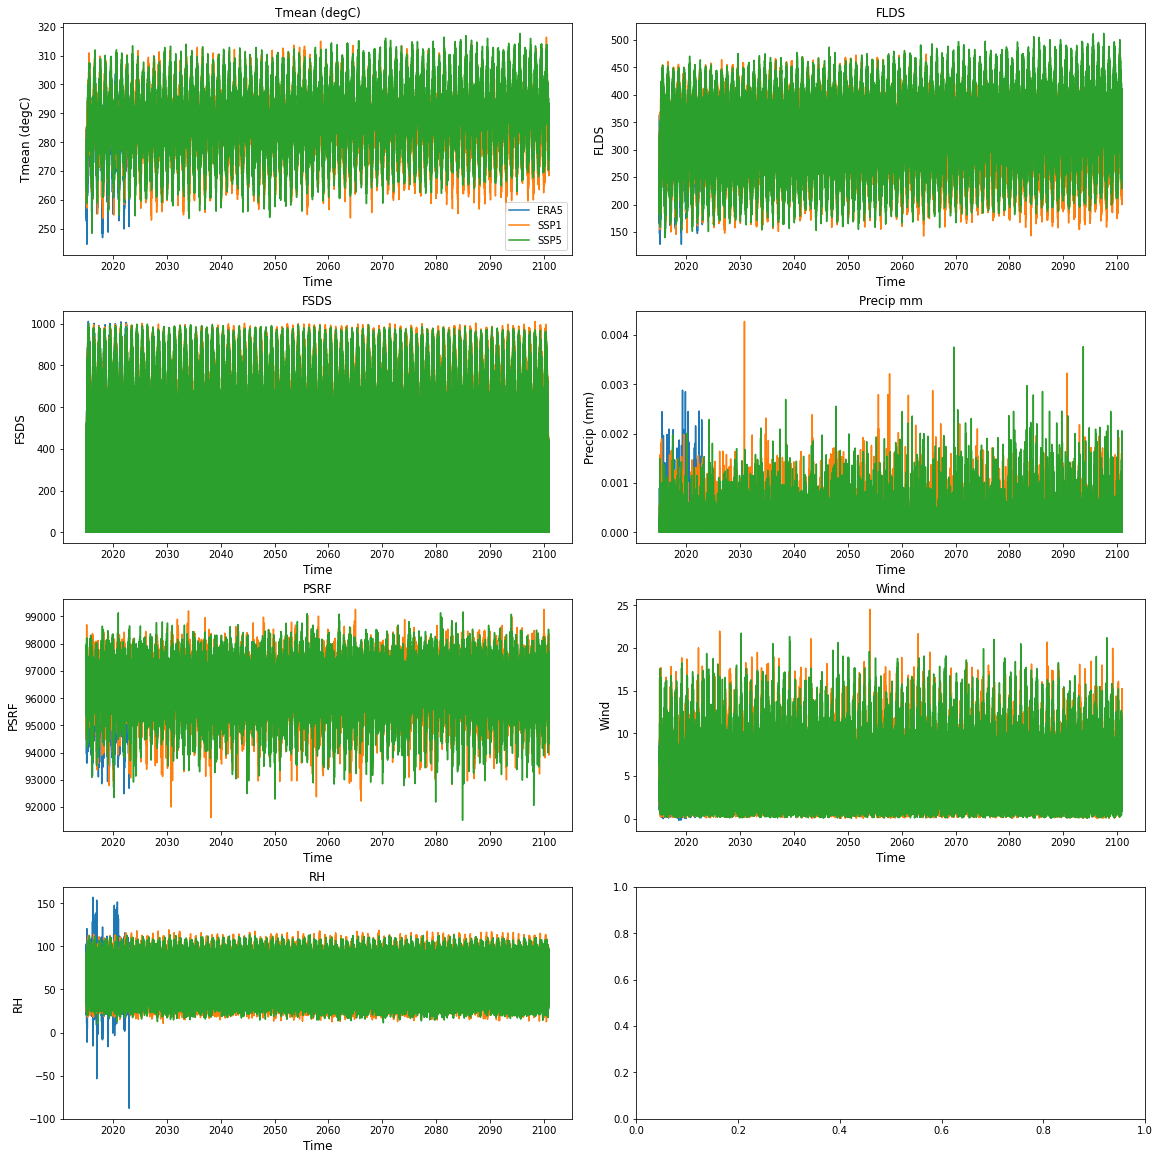

In [41]:
# quick plots as a sanity check  - seasonal cycle
fig1, ((f1ax0, f1ax1),(f1ax2, f1ax3),(f1ax4,f1ax5),(f1ax6,f1ax7)) = plt.subplots(nrows=4,ncols=2, figsize=(16,16), constrained_layout=True)


f1ax0.plot(era_time[0:70080], np.squeeze(era5_ts['TBOT']), label = 'ERA5')    
f1ax1.plot(era_time[0:70080], np.squeeze(era5_ts.FLDS))
f1ax2.plot(era_time[0:70080], np.squeeze(era5_ts.FSDS))
f1ax3.plot(era_time[0:70080], np.squeeze(era5_ts.PRECTmms))
f1ax4.plot(era_time[0:70080], np.squeeze(era5_ts.PSRF))
f1ax5.plot(era_time[0:70080], np.squeeze(era5_ts.WIND))
f1ax6.plot(era_time[0:70080], np.squeeze(era5_ts.RH))

f1ax0.plot(ssp_time[0:251120], np.squeeze(ssp1_ts.TBOT), label = 'SSP1')
f1ax1.plot(ssp_time[0:251120], np.squeeze(ssp1_ts.FLDS))
f1ax2.plot(ssp_time[0:251120], np.squeeze(ssp1_ts.FSDS))
f1ax3.plot(ssp_time[0:251120], np.squeeze(ssp1_ts.PRECTmms))
f1ax4.plot(ssp_time[0:251120], np.squeeze(ssp1_ts.PSRF))
f1ax5.plot(ssp_time[0:251120], np.squeeze(ssp1_ts.WIND))
f1ax6.plot(ssp_time[0:251120], np.squeeze(ssp1_ts.RH))

f1ax0.plot(ssp_time[0:251120], np.squeeze(ssp5_ts.TBOT), label='SSP5')    
f1ax1.plot(ssp_time[0:251120], np.squeeze(ssp5_ts.FLDS))
f1ax2.plot(ssp_time[0:251120], np.squeeze(ssp5_ts.FSDS))
f1ax3.plot(ssp_time[0:251120], np.squeeze(ssp5_ts.PRECTmms))
f1ax4.plot(ssp_time[0:251120], np.squeeze(ssp5_ts.PSRF))
f1ax5.plot(ssp_time[0:251120], np.squeeze(ssp5_ts.WIND))
f1ax6.plot(ssp_time[0:251120], np.squeeze(ssp5_ts.RH))

f1ax0.legend()

f1ax0.set_title(r'Tmean (degC)', fontsize = 12)
f1ax0.set_ylabel(r'Tmean (degC)', fontsize = 12)
f1ax0.set_xlabel(r'Time', fontsize = 12)    

f1ax1.set_title(r'FLDS', fontsize = 12)
f1ax1.set_ylabel(r'FLDS', fontsize = 12)
f1ax1.set_xlabel(r'Time', fontsize = 12)    

f1ax2.set_title(r'FSDS', fontsize = 12)
f1ax2.set_ylabel(r'FSDS', fontsize = 12)
f1ax2.set_xlabel(r'Time', fontsize = 12)    

f1ax3.set_title(r'Precip mm', fontsize = 12)
f1ax3.set_ylabel(r'Precip (mm)', fontsize = 12)
f1ax3.set_xlabel(r'Time', fontsize = 12) 

f1ax4.set_title(r'PSRF', fontsize = 12)
f1ax4.set_ylabel(r'PSRF', fontsize = 12)
f1ax4.set_xlabel(r'Time', fontsize = 12) 

f1ax5.set_title(r'Wind', fontsize = 12)
f1ax5.set_ylabel(r'Wind', fontsize = 12)
f1ax5.set_xlabel(r'Time', fontsize = 12) 

f1ax6.set_title(r'RH', fontsize = 12)
f1ax6.set_ylabel(r'RH', fontsize = 12)
f1ax6.set_xlabel(r'Time', fontsize = 12) 

### Now rename the variables and divide them back into monthly values  

In [42]:
ssp1_ts = ssp1_ts.drop_vars('FLDS')
ssp1_ts = ssp1_ts.drop_vars('FSDS')
ssp1_ts = ssp1_ts.drop_vars('PRECTmms')
ssp1_ts = ssp1_ts.drop_vars('QBOT')
ssp1_ts = ssp1_ts.drop_vars('TBOT')
ssp1_ts = ssp1_ts.drop_vars('WIND')
ssp1_ts = ssp1_ts.drop_vars('PSRF')
        
# rename the variables we do
ssp1_ts = ssp1_ts.rename({'FLDS_corr':'FLDS'})
ssp1_ts = ssp1_ts.rename({'FSDS_corr':'FSDS'})
ssp1_ts = ssp1_ts.rename({'PRECTmms_corr':'PRECTmms'})
ssp1_ts = ssp1_ts.rename({'TBOT_corr':'TBOT'})
ssp1_ts = ssp1_ts.rename({'WIND_corr':'WIND'})
ssp1_ts = ssp1_ts.rename({'PSRF_corr':'PSRF'})

In [43]:
grouped = ssp1_ts.groupby(ssp1_ts['time'].dt.strftime('%Y-%m'))
# Create a dictionary of { "YYYY-MM": subset_ds }
split_datasets = {key: grouped_obj for key, grouped_obj in grouped}

In [44]:
for key, subset in split_datasets.items():
    subset.to_netcdf(f'/pscratch/sd/j/jneedham/fates-mrv-runs/climate-forcing/PA/ssp1_corr/PA/CLM1PT_data/{key}.nc')

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/xarray/conventions.py:441: UserWarning: Variable 'time' has datetime type and a bounds variable but time.encoding does not have units specified. The units encodings for 'time' and 'time_bnds' will be determined independently and may not be equal, counter to CF-conventions. If this is a concern, specify a units encoding for 'time' before writing to a file.
  warnings.warn(


#### and SSP5

In [45]:
ssp5_ts = ssp5_ts.drop_vars('FLDS')
ssp5_ts = ssp5_ts.drop_vars('FSDS')
ssp5_ts = ssp5_ts.drop_vars('PRECTmms')
ssp5_ts = ssp5_ts.drop_vars('QBOT')
ssp5_ts = ssp5_ts.drop_vars('TBOT')
ssp5_ts = ssp5_ts.drop_vars('WIND')
ssp5_ts = ssp5_ts.drop_vars('PSRF')
        
# rename the variables we do
ssp5_ts = ssp5_ts.rename({'FLDS_corr':'FLDS'})
ssp5_ts = ssp5_ts.rename({'FSDS_corr':'FSDS'})
ssp5_ts = ssp5_ts.rename({'PRECTmms_corr':'PRECTmms'})
ssp5_ts = ssp5_ts.rename({'TBOT_corr':'TBOT'})
ssp5_ts = ssp5_ts.rename({'WIND_corr':'WIND'})
ssp5_ts = ssp5_ts.rename({'PSRF_corr':'PSRF'})

In [46]:
grouped = ssp5_ts.groupby(ssp5_ts['time'].dt.strftime('%Y-%m'))
# Create a dictionary of { "YYYY-MM": subset_ds }
split_datasets = {key: grouped_obj for key, grouped_obj in grouped}

for key, subset in split_datasets.items():
      subset.to_netcdf(f'/pscratch/sd/j/jneedham/fates-mrv-runs/climate-forcing/PA/ssp5_corr/PA/CLM1PT_data/{key}.nc')

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/xarray/conventions.py:441: UserWarning: Variable 'time' has datetime type and a bounds variable but time.encoding does not have units specified. The units encodings for 'time' and 'time_bnds' will be determined independently and may not be equal, counter to CF-conventions. If this is a concern, specify a units encoding for 'time' before writing to a file.
  warnings.warn(
